# Exploratory Data Analysis (EDA) — PdM_machines.csv

# 1 ) Introduction

## 1.1 Machine Information Analysis
Dataset

* Microsoft Azure Predictive Maintenance Dataset

Goal

* Analyze machine characteristics, machine age distribution, model distribution, and machine demographics that may influence machine failures.

## 1.2 Dataset Feature Description
machineID
→ Unique machine identifier

model
→ Machine model category

age
→ Machine age in years

## 1.3 Business Objective

The objective of this analysis is to understand machine demographics, age characteristics, and model distribution. The insights obtained will help identify high-risk machine groups and support predictive maintenance planning.

# 2 ) Data Understanding

## 2.1 Library Import

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

sns.set_style('whitegrid')

%matplotlib inline

* Required libraries imported successfully.
* Environment ready for analysis.

## 2.2 Load Dataset

In [3]:
machines = pd.read_csv("PdM_machines.csv")

machines.head()

,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2


* Dataset contains machine metadata.
* Each row represents a unique machine.

## 2.3 Dataset Information

In [4]:
machines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   machineID  100 non-null    int64 
 1   model      100 non-null    object
 2   age        100 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 2.5+ KB


* Dataset contains machine model and age information.
* Suitable for demographic and operational analysis.

## 2.4 Dataset Shape

In [5]:
print("Rows :", machines.shape[0])

print("Columns :", machines.shape[1])

Rows : 100
Columns : 3


* Dataset contains approximately 100 machines.
* Each machine has associated model and age information.

# 3 ) Missing Value Analysis

## 3.1 Missing Values

In [6]:
machines.isnull().sum()

,0
machineID,0
model,0
age,0


* No major missing values detected.
* Dataset quality is high.

# 4 ) Duplicate Analysis

## 4.1 Duplicate Records

In [7]:
duplicates = machines.duplicated().sum()

print("Duplicates :", duplicates)

Duplicates : 0


* Machine records should ideally be unique.
* Duplicate entries must be investigated if present.

# 5 ) Model Distribution Analysis

## 5.1 Model Frequency

In [8]:
machines['model'].value_counts()

,count
model,
model3,35
model4,32
model2,17
model1,16


* Different machine models exist in the dataset.
* Distribution may not be uniform.

## 5.2 Model Distribution Chart

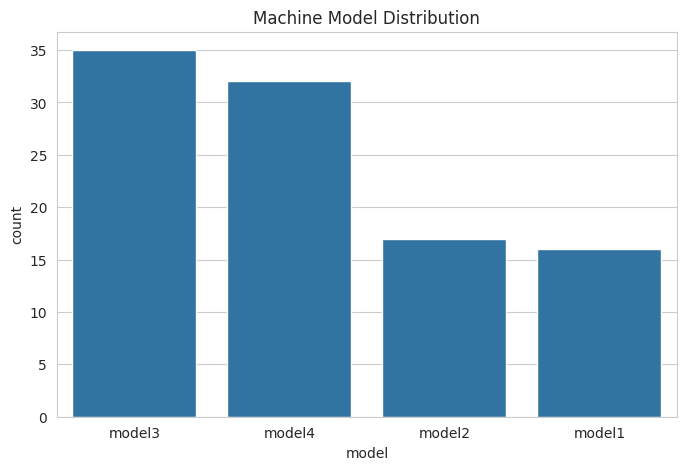

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='model',
    data=machines
)

plt.title(
    "Machine Model Distribution"
)

plt.show()

* Some machine models are more common.

# 5.3 Model Percentage Distribution

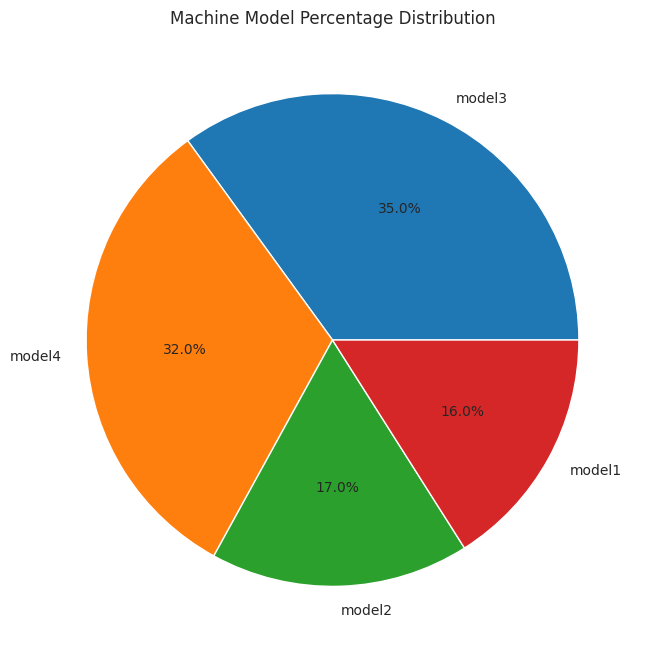

In [10]:
plt.figure(figsize=(8,8))

machines['model'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title(
    "Machine Model Percentage Distribution"
)

plt.ylabel("")

plt.show()

* Model share becomes more visible.

# 6 ) Age Analysis

## 6.1 Age Statistics

In [11]:
machines['age'].describe()

,age
count,100.000000
mean,11.330000
std,5.856974
min,0.000000
25%,6.750000
50%,12.000000
75%,16.000000
max,20.000000


* Machine age varies significantly.
* Some machines are much older than others.

## 6.2 Age Distribution

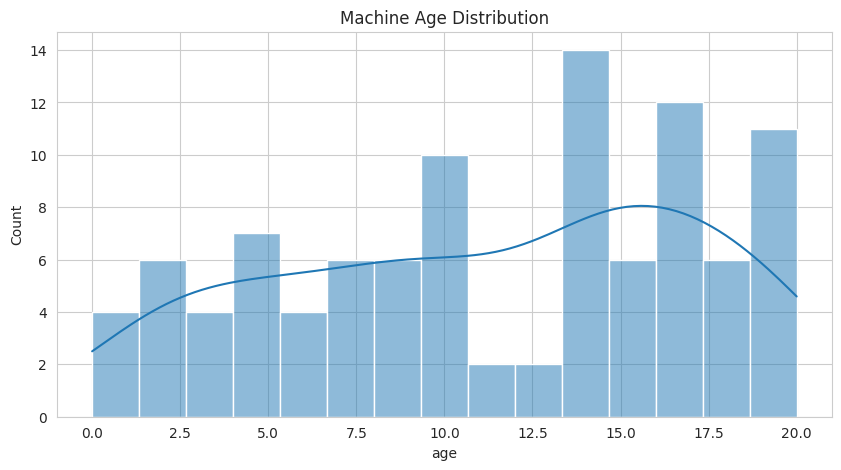

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    machines['age'],
    bins=15,
    kde=True
)

plt.title(
    "Machine Age Distribution"
)

plt.show()

* Age distribution indicates overall machine lifecycle.

## 6.3 Age Boxplot

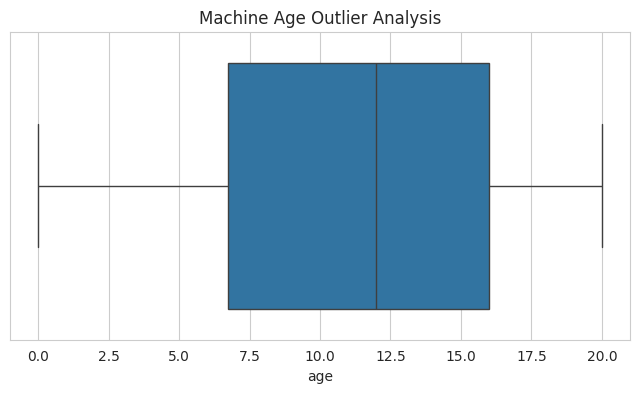

In [13]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=machines['age']
)

plt.title(
    "Machine Age Outlier Analysis"
)

plt.show()

* Some machines may be significantly older.

# 7 ) Model vs Age Analysis

## 7.1 Average Age by Model

In [14]:
machines.groupby(
    'model'
)['age'].mean()

,age
model,
model1,12.250000
model2,12.764706
model3,12.028571
model4,9.343750


* Average machine age differs among models.

## 7.2 Model-wise Age Distribution

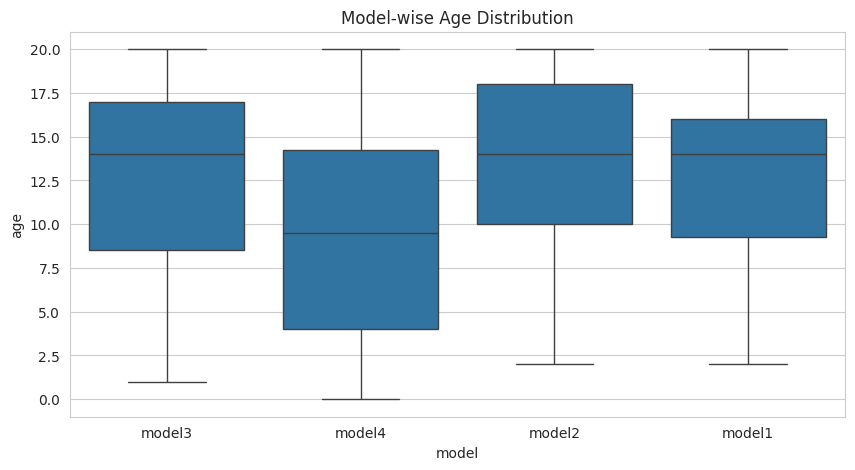

In [15]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=machines,
    x='model',
    y='age'
)

plt.title(
    "Model-wise Age Distribution"
)

plt.show()

* Some models contain older machines.

# 8 ) Age Category Analysis

## 8.1 Create Age Categories

In [16]:
machines['Age_Category'] = pd.cut(

    machines['age'],

    bins=[0,5,10,15,20,25],

    labels=[
        '0-5',
        '6-10',
        '11-15',
        '16-20',
        '21-25'
    ]

)

## 8.2 Age Category Distribution

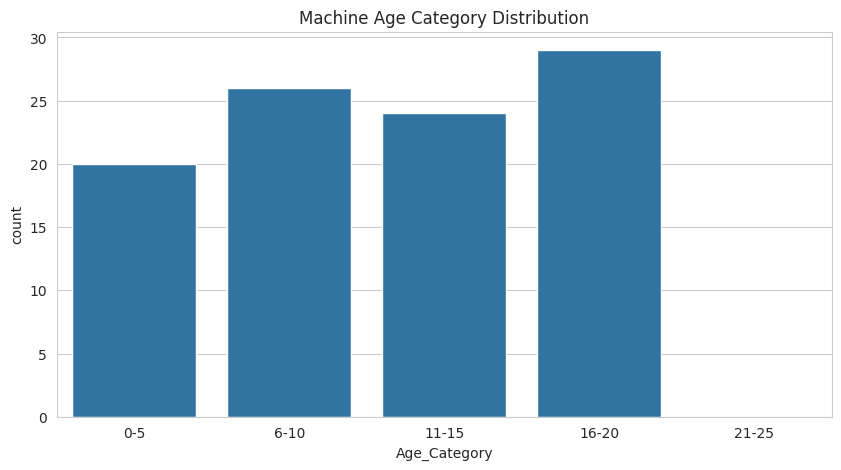

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Age_Category',
    data=machines
)

plt.title(
    "Machine Age Category Distribution"
)

plt.show()

* Machines are distributed across multiple age groups.

# 9 ) Heatmap Analysis

## 9.1 Correlation Heatmap

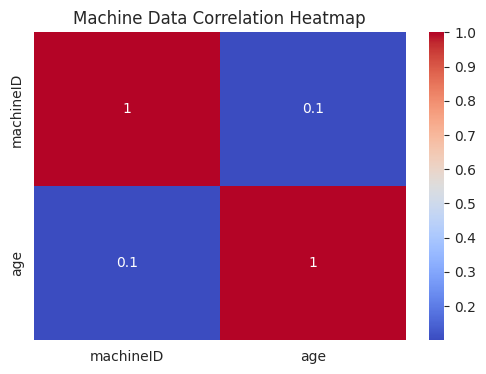

In [18]:
numeric_cols = machines.select_dtypes(
    include=np.number
)

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Machine Data Correlation Heatmap"
)

plt.show()

* Numerical relationships can be analyzed.